In [42]:
# Standard scientific libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize

# Set plotting style for better visualization
plt.style.use("seaborn-v0_8")

Viral Load Data:
   time  value
0     0  2.584
1     8  3.791
2    24  4.566
3    48  5.138
4    72  4.338 

Interferon Data:
   time  value
0     0  2.138
1     8  2.203
2    24  3.629
3    48  5.961
4    72  5.248


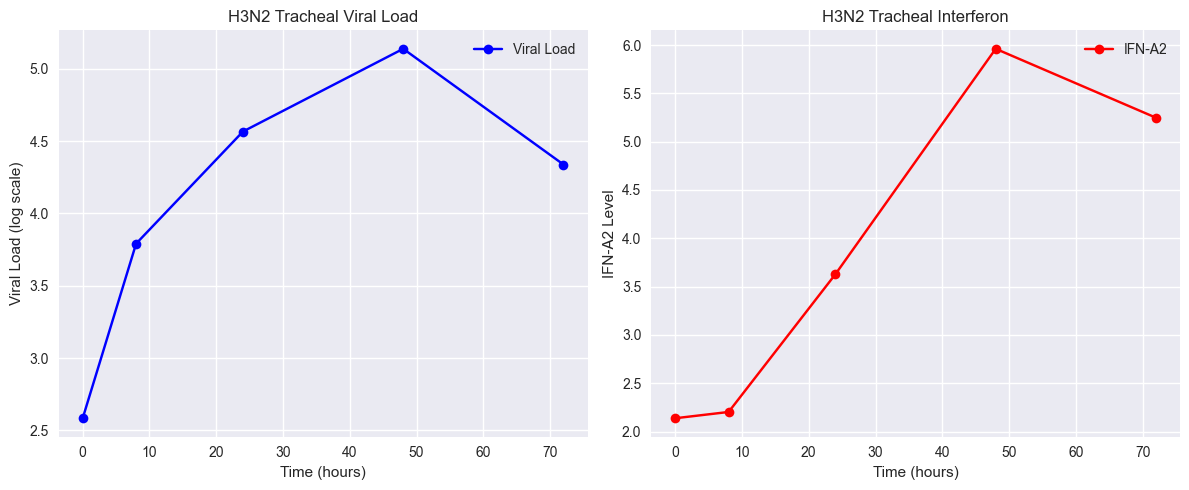

In [43]:
vl_path = "/Users/arjansuri/Desktop/Projects/TCU/BirdFlu/data/tracheal_data/h5n1(2005)/tracheal_h5n1_2005_vl.txt"
t1_path = "/Users/arjansuri/Desktop/Projects/TCU/BirdFlu/data/tracheal_data/h5n1(2005)/tracheal_h5n1_2005_t1.txt"

# Load the viral load data
vl_data = pd.read_csv(vl_path)
print("Viral Load Data:")
print(vl_data, "\n")

# Load the interferon data
t1_data = pd.read_csv(t1_path)
print("Interferon Data:")
print(t1_data)

# Let's also create a simple plot to visualize our data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot viral load data
ax1.plot(vl_data['time'], vl_data['value'], 'o-', color='blue', label='Viral Load')
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Viral Load (log scale)')
ax1.set_title('H3N2 Tracheal Viral Load')
ax1.legend()

# Plot interferon data
ax2.plot(t1_data['time'], t1_data['value'], 'o-', color='red', label='IFN-A2')
ax2.set_xlabel('Time (hours)')
ax2.set_ylabel('IFN-A2 Level')
ax2.set_title('H3N2 Tracheal Interferon')
ax2.legend()

plt.tight_layout()
plt.savefig('nasal_h3n2.png')
plt.show()

In [44]:
def Model(y, t, beta, delta, p, c, epsilon, alpha):
    """
    Model 1: Interferon affects infection rate
    
    Parameters:
    y: list of variables [T, I, V, F]
    t: time points
    beta: infection rate
    delta: death rate of infected cells
    p: virus production rate
    c: virus clearance rate
    epsilon: interferon effect strength
    alpha: interferon clearance rate
    
    Returns:
    List of derivatives [dT/dt, dI/dt, dV/dt, dF/dt]
    """
    T, I, V, F = y
    
    # System of ODEs
    dTdt = -beta * T * V    # Target cells
    dIdt = beta * T * V - delta * I    # Infected cells
    dVdt = (p/(epsilon+F)) * I - c * V    # Virus
    dFdt = I - alpha * F    # Interferon
    
    return [dTdt, dIdt, dVdt, dFdt]


# Initial conditions
T0 = 1.0     # Initial target cells (normalized)
I0 = 0.0     # Initial infected cells
V0 = vl_data['value'].iloc[0]    # Initial virus from data
F0 = t1_data['value'].iloc[0]    # Initial interferon from data
y0 = [T0, I0, V0, F0]

print("Initial conditions:")
print(f"T0 = {T0}")
print(f"I0 = {I0}")
print(f"V0 = {V0}")
print(f"F0 = {F0}")

Initial conditions:
T0 = 1.0
I0 = 0.0
V0 = 2.584
F0 = 2.138


In [45]:
# Create two sets of time points:
# 1. Data time points for comparison
data_times = np.array([0, 8, 24, 48, 72])

# 2. Integration time points (finer mesh for solving ODEs)
# Using 100 points for smooth integration
t = np.linspace(0, 72, 100)

def optimize(params):
    beta, delta, p, c, epsilon, alpha = params
    
    # Solve ODE system
    solution = odeint(Model, y0, data_times, args=(beta, delta, p, c, epsilon, alpha))
    T, I, V, F = solution.T
    
    # Calculate SSR directly
    vl_ssr = np.sum((((np.maximum(V, 0)) - vl_data['value'])/vl_data['value'])**2)
    ifn_ssr = np.sum(((F - t1_data['value'])/t1_data['value'])**2)
    
    total_ssr = vl_ssr + ifn_ssr
    
    print(f"Parameters: {params} | SSR: {total_ssr}")
    return total_ssr

print("Data time points:", data_times)
print("\nNumber of integration points:", len(t))
print("Integration time range:", t[0], "to", t[-1])

Data time points: [ 0  8 24 48 72]

Number of integration points: 100
Integration time range: 0.0 to 72.0


In [46]:
# guess =  [5, 2, .1, 0.3, 0.2, 1]
# guess =  [8.343820383462457, 0.14227915640397182, 24.999803292031743, 1.0000000000000006e-06, 9.943491537961386, 99.99999705549871]
# guess =  [14.99962824221421, 0.14325122860273118, 25.0, 1.0041844271121745e-06, 9.999991155086164, 99.99999433433749]
# guess =  [18157.22935023227, 0.2675500608913878, 3188.941873829718, -0.0044186634094281335, 121.52095549498222, 102099.2414743583]
# guess =  [12.462564035211152, 0.26890545724797177, 24.4609077003097, 0.004419028064124291, 16.60630496689475, 10.03528493777]
# guess =  [33.7023621186502087, 0.11169188982976419, 6.500142109750015, 0.002728635855545944, 12.962759191783146, 24.97498620729047]
# guess =  [np.float64(9.73022706705976), np.float64(0.14705740036139425), np.float64(10.482899086173001), np.float64(0.0001001617005785607), np.float64(19.586219970862402), np.float64(49.99931161312256)]
# guess =  [np.float64(95.02768120275016), np.float64(0.03851942379976944), np.float64(99.9956199846182), np.float64(0.0014071999313988474), np.float64(0.0001000000000000026), np.float64(12.033396988200224)]
# guess =  [np.float64(99.95319080865168), np.float64(0.03677078825573739), np.float64(2.031858793925287), np.float64(0.00010000000000000005), np.float64(0.00010000000000000015), np.float64(0.3836716139186588)]
guess =  [np.float64(99.95319080865168), np.float64(0.03677078825573739), np.float64(2.031858793925287), np.float64(0.00010000000000000005), np.float64(0.00010000000000000015), np.float64(0.3836716139186588)]
guess =  [np.float64(99.95319080865168), np.float64(0.09677078825573739), np.float64(2.031858793925287), np.float64(0.0010000000000000005), np.float64(0.00010000000000000015), np.float64(0.3836716139186588)]
guess =  [np.float64(90.0), np.float64(0.091543456985766048), np.float64(2.078163187599643), np.float64(0.004702434269333774), np.float64(0.00017175207026455405), np.float64(0.3504507905434472)]


In [47]:
# # Initial parameter guesses
# guess = [
#     3.1222517400768077,  # beta: infection rate
#     0.47603955892757216, # delta: death rate of infected cells  
#     1.2237785870982805,  # p: virus production rate
#     0.6025090572080625,  # c: virus clearance rate
#     0.18207561887227228, # epsilon: interferon effect strength
#     1.8112115806320495   # alpha: interferon clearance rate
# ]

# Parameter bounds
bounds = [
    (10e-5, 100),   # beta: infection rate bounds
    (10e-5, 10),   # delta: death rate bounds
    (10e-5, 100),   # p: production rate bounds
    (10e-5, 20),   # c: clearance rate bounds
    (10e-5, 20),   # epsilon: interferon effect bounds
    (0.0001, 50)   # alpha: interferon clearance bounds
]

print("Initial parameter guesses:")
for param, value in zip(['beta', 'delta', 'p', 'c', 'epsilon', 'alpha'], guess):
    print(f"{param}: {value}")

Initial parameter guesses:
beta: 90.0
delta: 0.09154345698576605
p: 2.078163187599643
c: 0.004702434269333774
epsilon: 0.00017175207026455405
alpha: 0.3504507905434472


In [48]:
# Perform optimization
result = minimize(optimize, guess, method='Nelder-Mead', bounds=bounds, )

# Extract optimized parameters
beta_fit, delta_fit, p_fit, c_fit, epsilon_fit, alpha_fit = result.x

# Generate solution with optimized parameters
solution_fit = odeint(Model, y0, t, args=(beta_fit, delta_fit, p_fit, c_fit, epsilon_fit, alpha_fit))
T_fit, I_fit, V_fit, F_fit = solution_fit.T

# Print optimization results
print("Optimization successful:", result.success)
print("Number of iterations:", result.nit)
print("\nOptimized parameters:")
param_names = ['beta', 'delta', 'p', 'c', 'epsilon', 'alpha']
for name, value in zip(param_names, result.x):
    print(f"{name}: {value:.6f}")

print("guess = ", [i for i in result.x])

Parameters: [9.00000000e+01 9.15434570e-02 2.07816319e+00 4.70243427e-03
 1.71752070e-04 3.50450791e-01] | SSR: 77.85573579158047
Parameters: [9.45000000e+01 9.15434570e-02 2.07816319e+00 4.70243427e-03
 1.71752070e-04 3.50450791e-01] | SSR: 77.85553013118167
Parameters: [9.00000000e+01 9.61206298e-02 2.07816319e+00 4.70243427e-03
 1.71752070e-04 3.50450791e-01] | SSR: 75.09487620714667
Parameters: [9.00000000e+01 9.15434570e-02 2.18207135e+00 4.70243427e-03
 1.71752070e-04 3.50450791e-01] | SSR: 86.40539457658471
Parameters: [9.00000000e+01 9.15434570e-02 2.07816319e+00 4.93755598e-03
 1.71752070e-04 3.50450791e-01] | SSR: 76.53824586467746
Parameters: [9.00000000e+01 9.15434570e-02 2.07816319e+00 4.70243427e-03
 1.80339674e-04 3.50450791e-01] | SSR: 77.82511679167496
Parameters: [9.00000000e+01 9.15434570e-02 2.07816319e+00 4.70243427e-03
 1.71752070e-04 3.67973330e-01] | SSR: 88.3216930876534
Parameters: [9.15000000e+01 9.30691813e-02 2.11279924e+00 4.78080817e-03
 1.74614605e-04 3.


Final SSR: 0.124526


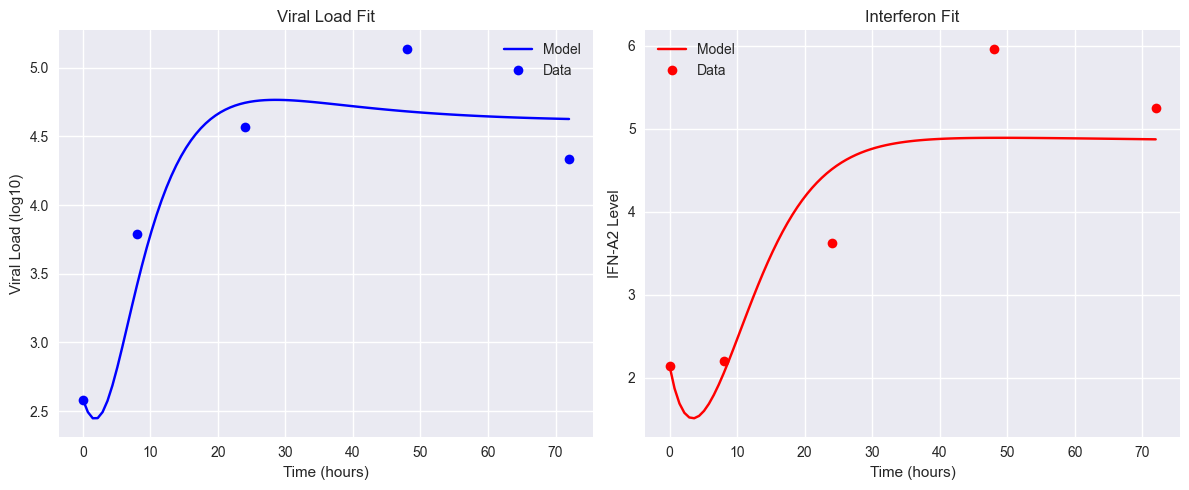

In [49]:
# Calculate final SSR
final_ssr = result.fun
print(f"\nFinal SSR: {final_ssr:.6f}")

# Plot results
plt.figure(figsize=(12, 5))

# Plot viral load
plt.subplot(121)
plt.plot(t, (V_fit), 'b-', label='Model')
plt.plot(vl_data['time'], vl_data['value'], 'bo', label='Data')
plt.xlabel('Time (hours)')
plt.ylabel('Viral Load (log10)')
plt.legend()
plt.title('Viral Load Fit')

# Plot interferon
plt.subplot(122)
plt.plot(t, F_fit, 'r-', label='Model')
plt.plot(t1_data['time'], t1_data['value'], 'ro', label='Data')
plt.xlabel('Time (hours)')
plt.ylabel('IFN-A2 Level')
plt.legend()
plt.title('Interferon Fit')

plt.tight_layout()
plt.savefig("tracheal_fit_h3n2.png")
plt.show()